# VAE on Dataset3 T2 volumes

Trains a small 2D convolutional VAE on axial slices from the **T2 volumes of dataset3** only
(`dataset3/val_gallery.csv` + `dataset3/test_gallery.csv` — dataset3 has no labelled training
pairs, only galleries). The goal is a compact, denoised T2 slice representation/reconstruction
for dataset3, independent of the various retrieval-method scripts (those were moved to
`archive/src_scripts/`).

Pipeline:
1. List every T2 volume referenced by dataset3's val/test galleries.
2. Load each NIfTI volume, clip/normalize intensities, sample evenly-spaced axial slices, resize to a fixed size.
3. Split volumes (not slices) into train/val so validation slices come from unseen patients.
4. Train a convolutional VAE (MSE reconstruction + KL) on MPS.
5. Plot the loss curve and visualize original vs. reconstructed slices.

In [1]:
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from skimage.transform import resize
from torch import nn
from torch.utils.data import DataLoader, Dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# --- Config ---
DATA_ROOT = Path("../data/ehl-paris-medical-image-retrieval")
DATASET3_CSVS = [DATA_ROOT / "dataset3" / "val_gallery.csv", DATA_ROOT / "dataset3" / "test_gallery.csv"]

NUM_SLICES = 24          # axial slices sampled per volume
IMAGE_SIZE = 96          # resize each slice to IMAGE_SIZE x IMAGE_SIZE
AXIS = 2                 # axial axis in the (H, W, D) volume
VAL_FRACTION = 0.15       # held-out volumes (not slices) for validation

LATENT_DIM = 128
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
KL_WEIGHT = 1e-4

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
)
print(f"Using device: {DEVICE}")

CHECKPOINT_PATH = Path("../checkpoints/vae_dataset3_t2.pt")

Using device: mps


## 1. List dataset3 T2 volumes

Only the gallery columns of dataset3 are T2 (queries are ceT1). The CSVs reference `.nii.gz`
paths but some files on disk are plain `.nii`, so the path resolver falls back to the
extension that actually exists.

In [3]:
def resolve_path(data_root: Path, image_path: str) -> Path:
    path = Path(image_path)
    resolved = path if path.is_absolute() else data_root / path
    if resolved.exists():
        return resolved
    if resolved.name.endswith(".nii.gz"):
        fallback = resolved.with_name(resolved.name[:-3])  # strip ".gz"
        if fallback.exists():
            return fallback
    elif resolved.suffix == ".nii":
        fallback = resolved.with_name(resolved.name + ".gz")
        if fallback.exists():
            return fallback
    raise FileNotFoundError(f"Could not resolve volume path: {image_path}")


def list_dataset3_t2_volumes(data_root: Path, csv_paths: list[Path]) -> list[Path]:
    volumes = []
    for csv_path in csv_paths:
        with csv_path.open(newline="") as f:
            for row in csv.DictReader(f):
                assert row["target_modality"] == "T2", f"Expected T2, got {row['target_modality']}"
                volumes.append(resolve_path(data_root, row["target_image"]))
    return volumes


t2_volume_paths = list_dataset3_t2_volumes(DATA_ROOT, DATASET3_CSVS)
print(f"Found {len(t2_volume_paths)} dataset3 T2 volumes")
print(t2_volume_paths[:3])

Found 97 dataset3 T2 volumes
[PosixPath('../data/ehl-paris-medical-image-retrieval/dataset3/images/val/gallery/g_099f934e990e.nii'), PosixPath('../data/ehl-paris-medical-image-retrieval/dataset3/images/val/gallery/g_53fcbbdbcbd8.nii'), PosixPath('../data/ehl-paris-medical-image-retrieval/dataset3/images/val/gallery/g_e81c69ee2327.nii')]


## 2. Preprocessing

Each volume is clipped to its 1st/99th intensity percentile, min-max normalized to `[0, 1]`
(the VAE decoder ends in a sigmoid, so targets must be in `[0, 1]`), then `NUM_SLICES`
evenly-spaced axial slices are extracted and resized to `IMAGE_SIZE x IMAGE_SIZE`.

preprocessed shape: (24, 96, 96) range: 0.0 1.0


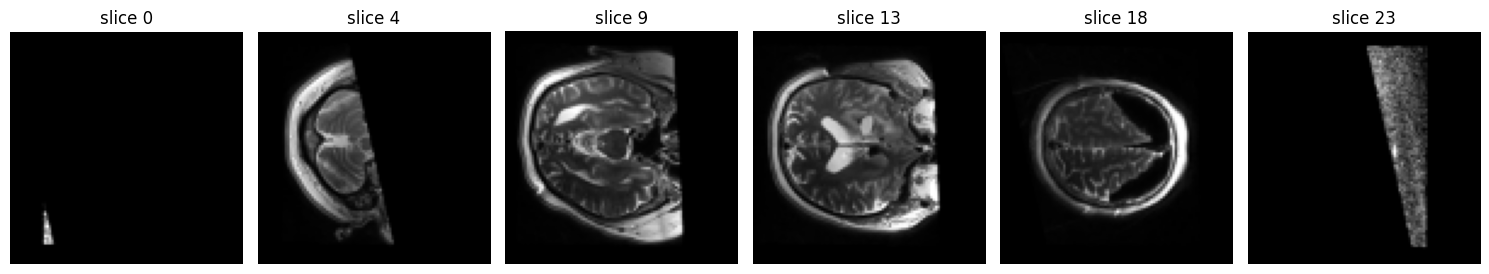

In [4]:
def load_nifti(path: Path) -> np.ndarray:
    volume = np.asarray(nib.load(str(path)).get_fdata(dtype=np.float32))
    return np.nan_to_num(volume, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def preprocess_volume(
    volume: np.ndarray,
    num_slices: int = NUM_SLICES,
    image_size: int = IMAGE_SIZE,
    axis: int = AXIS,
) -> np.ndarray:
    """(H, W, D) MRI volume -> (num_slices, image_size, image_size) float32 in [0, 1]."""
    finite = volume[volume != 0]
    if finite.size:
        p_low, p_high = np.percentile(finite, [1, 99])
        volume = np.clip(volume, p_low, p_high)
        low, high = float(volume.min()), float(volume.max())
        volume = (volume - low) / max(high - low, 1e-6)

    depth = volume.shape[axis]
    indices = np.linspace(0, depth - 1, num_slices).round().astype(int)
    slices = np.moveaxis(np.take(volume, indices, axis=axis), axis, 0)  # (K, H, W)

    out = np.empty((num_slices, image_size, image_size), dtype=np.float32)
    for k in range(num_slices):
        out[k] = resize(slices[k], (image_size, image_size), order=1, mode="edge", anti_aliasing=True, preserve_range=True)
    return out


# Sanity check on one volume
sample_slices = preprocess_volume(load_nifti(t2_volume_paths[0]))
print("preprocessed shape:", sample_slices.shape, "range:", sample_slices.min(), sample_slices.max())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, idx in zip(axes, np.linspace(0, NUM_SLICES - 1, 6).astype(int)):
    ax.imshow(sample_slices[idx], cmap="gray")
    ax.set_title(f"slice {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset and train/val split

All slices from all volumes are precomputed once and kept in memory (99 volumes x 24 slices x
96x96 float32 is small, ~85 MB). The split is by **volume**, not by slice, so validation slices
come from held-out patients.

In [5]:
class SliceDataset(Dataset):
    """Flat (N_slices, 1, H, W) view over a list of preprocessed volumes."""

    def __init__(self, volume_slices: list[np.ndarray]) -> None:
        self.slices = np.concatenate(volume_slices, axis=0)  # (N, H, W)

    def __len__(self) -> int:
        return len(self.slices)

    def __getitem__(self, index: int) -> torch.Tensor:
        return torch.from_numpy(self.slices[index]).unsqueeze(0)  # (1, H, W)


shuffled_paths = t2_volume_paths.copy()
random.Random(42).shuffle(shuffled_paths)
n_val = max(1, round(len(shuffled_paths) * VAL_FRACTION))
val_paths, train_paths = shuffled_paths[:n_val], shuffled_paths[n_val:]
print(f"Train volumes: {len(train_paths)}  Validation volumes: {len(val_paths)}")

train_volume_slices = [preprocess_volume(load_nifti(p)) for p in train_paths]
val_volume_slices = [preprocess_volume(load_nifti(p)) for p in val_paths]

train_dataset = SliceDataset(train_volume_slices)
val_dataset = SliceDataset(val_volume_slices)
print(f"Train slices: {len(train_dataset)}  Validation slices: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train volumes: 82  Validation volumes: 15
Train slices: 1968  Validation slices: 360


## 4. Model: convolutional VAE

A small 3-layer conv encoder/decoder. `IMAGE_SIZE` must be divisible by 8 (three stride-2
convs) — 96 / 8 = 12, so the bottleneck feature map is 12x12.

In [6]:
class ConvVAE(nn.Module):
    def __init__(self, image_size: int = IMAGE_SIZE, latent_dim: int = LATENT_DIM) -> None:
        super().__init__()
        assert image_size % 8 == 0, "image_size must be divisible by 8"
        self.image_size = image_size
        self.bottleneck = image_size // 8

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.SiLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.SiLU(),
            nn.Flatten(),
        )
        flat_dim = 128 * self.bottleneck * self.bottleneck
        self.mu = nn.Linear(flat_dim, latent_dim)
        self.logvar = nn.Linear(flat_dim, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.SiLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.SiLU(),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        hidden = self.encoder(x)
        return self.mu(hidden), self.logvar(hidden).clamp(-8, 8)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        x = self.decoder_fc(z).view(-1, 128, self.bottleneck, self.bottleneck)
        return self.decoder(x)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar


model = ConvVAE().to(DEVICE)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (mu): Linear(in_features=18432, out_features=128, bias=True)
  (logvar): Linear(in_features=18432, out_features=128, bias=True)
  (decoder_fc): Linear(in_features=128, out_features=18432, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## 5. Training loop

Loss = MSE reconstruction + `KL_WEIGHT * KL(q(z|x) || N(0, I))`. KL is kept small relative to
reconstruction since the goal is sharp reconstructions, not a heavily regularized latent space.

In [7]:
def vae_loss(recon: torch.Tensor, target: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> dict[str, torch.Tensor]:
    recon_loss = F.mse_loss(recon, target)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return {"loss": recon_loss + KL_WEIGHT * kl, "recon": recon_loss, "kl": kl}


@torch.no_grad()
def evaluate(model: ConvVAE, loader: DataLoader) -> dict[str, float]:
    model.eval()
    totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
    count = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        recon, mu, logvar = model(batch)
        parts = vae_loss(recon, batch, mu, logvar)
        for key in totals:
            totals[key] += float(parts[key].item()) * len(batch)
        count += len(batch)
    return {key: value / max(count, 1) for key, value in totals.items()}


def train(model: ConvVAE, train_loader: DataLoader, val_loader: DataLoader, epochs: int, lr: float) -> list[dict[str, float]]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
        count = 0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            recon, mu, logvar = model(batch)
            parts = vae_loss(recon, batch, mu, logvar)
            optimizer.zero_grad(set_to_none=True)
            parts["loss"].backward()
            optimizer.step()
            for key in totals:
                totals[key] += float(parts[key].item()) * len(batch)
            count += len(batch)
        train_metrics = {key: value / max(count, 1) for key, value in totals.items()}
        val_metrics = evaluate(model, val_loader)
        print(
            f"epoch {epoch}/{epochs}  train_loss={train_metrics['loss']:.5f} (recon={train_metrics['recon']:.5f}, kl={train_metrics['kl']:.5f})"
            f"  val_loss={val_metrics['loss']:.5f} (recon={val_metrics['recon']:.5f})"
        )
        history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}})
    return history


history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

epoch 1/40  train_loss=0.07055 (recon=0.06984, kl=7.02899)  val_loss=0.02337 (recon=0.02248)
epoch 2/40  train_loss=0.01348 (recon=0.01290, kl=5.83587)  val_loss=0.01148 (recon=0.01090)
epoch 3/40  train_loss=0.00957 (recon=0.00906, kl=5.11508)  val_loss=0.00962 (recon=0.00912)
epoch 4/40  train_loss=0.00815 (recon=0.00765, kl=4.92020)  val_loss=0.00837 (recon=0.00793)
epoch 5/40  train_loss=0.00724 (recon=0.00679, kl=4.42383)  val_loss=0.00820 (recon=0.00781)
epoch 6/40  train_loss=0.00639 (recon=0.00601, kl=3.76950)  val_loss=0.00715 (recon=0.00678)


KeyboardInterrupt: 

## 6. Loss curve

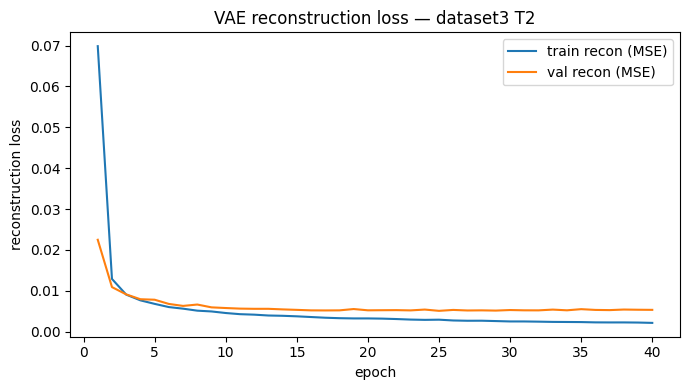

In [ ]:
epochs = [h["epoch"] for h in history]
plt.figure(figsize=(7, 4))
plt.plot(epochs, [h["train_recon"] for h in history], label="train recon (MSE)")
plt.plot(epochs, [h["val_recon"] for h in history], label="val recon (MSE)")
plt.xlabel("epoch")
plt.ylabel("reconstruction loss")
plt.legend()
plt.title("VAE reconstruction loss — dataset3 T2")
plt.tight_layout()
plt.show()

## 7. Visualize reconstructions on held-out validation slices

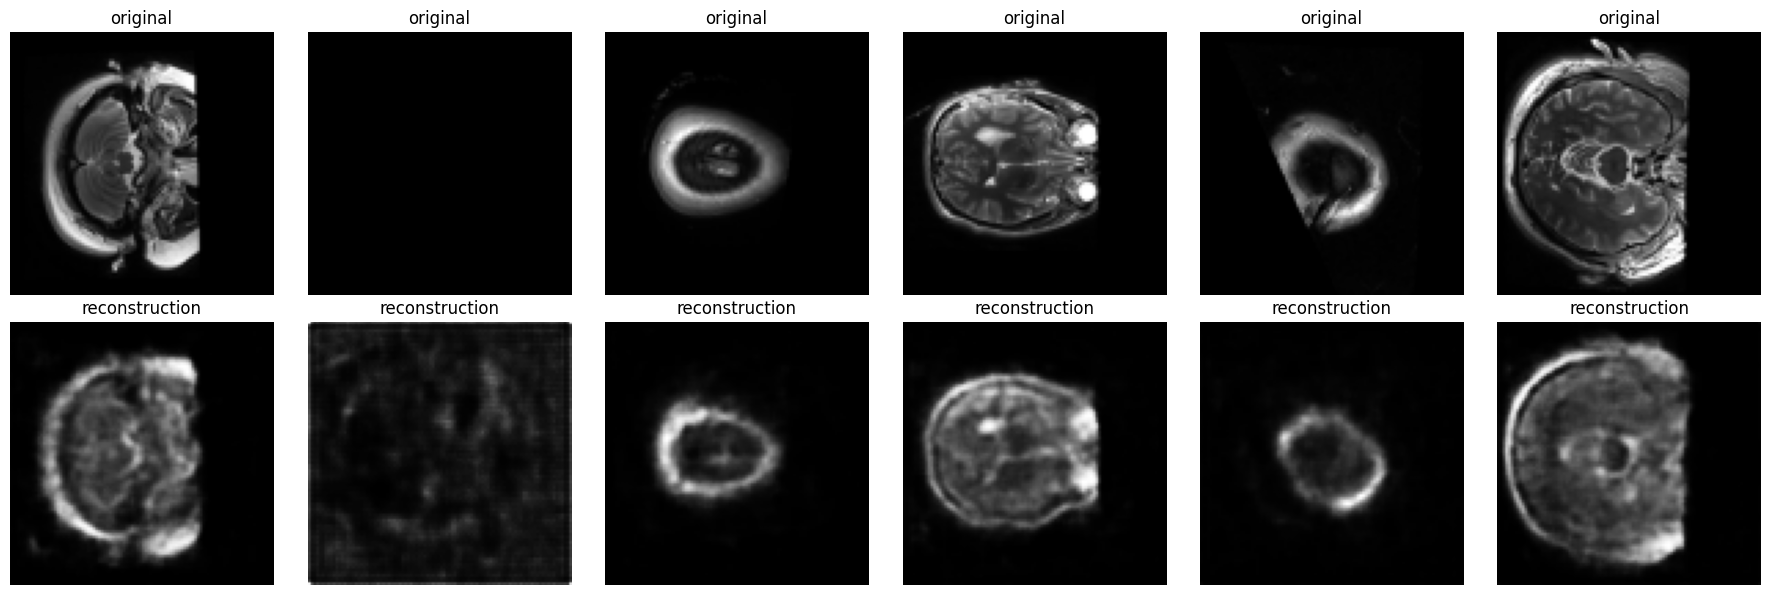

In [ ]:
model.eval()
sample_indices = random.Random(0).sample(range(len(val_dataset)), k=min(6, len(val_dataset)))
originals = torch.stack([val_dataset[i] for i in sample_indices]).to(DEVICE)
with torch.no_grad():
    reconstructions, _, _ = model(originals)

fig, axes = plt.subplots(2, len(sample_indices), figsize=(3 * len(sample_indices), 6))
for col in range(len(sample_indices)):
    axes[0, col].imshow(originals[col, 0].cpu(), cmap="gray")
    axes[0, col].set_title("original")
    axes[0, col].axis("off")
    axes[1, col].imshow(reconstructions[col, 0].cpu(), cmap="gray")
    axes[1, col].set_title("reconstruction")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()

## 8. Save checkpoint

In [ ]:
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "state_dict": model.state_dict(),
        "image_size": IMAGE_SIZE,
        "latent_dim": LATENT_DIM,
        "num_slices": NUM_SLICES,
        "axis": AXIS,
    },
    CHECKPOINT_PATH,
)
print(f"Saved checkpoint: {CHECKPOINT_PATH}")

Saved checkpoint: ../checkpoints/vae_dataset3_t2.pt
